# Particle Filter

A particle filter for 2D localization from range measurements to known
landmarks. Unlike the Kalman family, the particle filter doesn't assume the
posterior is Gaussian — it represents $p(\mathbf{x}_t \mid \mathbf{z}_{1:t})$
with a swarm of weighted samples.

The original script in this repo drove the robot interactively via OpenCV
mouse callbacks. That can't run in a notebook, so here we drive the robot
along a **synthetic circular trajectory** and watch the particle cloud
collapse onto it as range measurements accumulate.


## Particle filter recursion

We approximate the posterior with $N$ weighted samples
$\{(\mathbf{x}^{(i)}_t, w^{(i)}_t)\}_{i=1}^{N}$.

**1. Predict.** Push each particle through the (noisy) motion model:

$$
\mathbf{x}^{(i)}_t = f\!\left(\mathbf{x}^{(i)}_{t-1}, \mathbf{u}_t\right) + \boldsymbol{\epsilon}^{(i)}, \quad \boldsymbol{\epsilon}^{(i)} \sim \mathcal{N}(0, \Sigma)
$$

**2. Weight.** Score each particle by how well it explains the measurement.
For range measurements $\mathbf{z}_t = \{z_t^{(\ell)}\}$ to landmarks
$\{\mathbf{m}^{(\ell)}\}$:

$$
w^{(i)}_t \;\propto\; \prod_{\ell} \mathcal{N}\!\left(z_t^{(\ell)} \;\middle|\; \|\mathbf{x}^{(i)}_t - \mathbf{m}^{(\ell)}\|, R\right)
$$

then normalize so $\sum_i w^{(i)}_t = 1$.

**3. Resample.** Draw $N$ new particles from the weighted set so that
high-weight particles survive and low-weight ones die. We use **systematic
resampling**, which has lower variance than multinomial resampling.

**Estimate.** Report the weighted mean of the particles as the point
estimate:

$$
\hat{\mathbf{x}}_t = \sum_{i=1}^{N} w^{(i)}_t \mathbf{x}^{(i)}_t
$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

rng = np.random.default_rng(seed=0)

# World — 800 x 600 (matches original script)
WORLD_W, WORLD_H = 800, 600

# Six landmarks the robot can range-measure
landmarks = np.array([
    [144,  73],
    [410,  13],
    [336, 175],
    [718, 159],
    [178, 484],
    [665, 464],
], dtype=float)

# Measurement noise std (pixels)
SENSOR_STD = 5.0


## Particle initialization

In [2]:
N = 400  # number of particles

def uniform_particles(x_range, y_range, n):
    p = np.empty((n, 2))
    p[:, 0] = rng.uniform(*x_range, size=n)
    p[:, 1] = rng.uniform(*y_range, size=n)
    return p

particles = uniform_particles((0, WORLD_W), (0, WORLD_H), N)
weights   = np.ones(N) / N


## Motion, weighting, resampling

In [3]:
def predict(particles, heading, distance, std):
    """Move each particle by `distance` along `heading`, with Gaussian noise."""
    n = len(particles)
    d = distance + rng.normal(0.0, std[1], size=n)
    particles[:, 0] += np.cos(heading) * d + rng.normal(0.0, std[0], size=n)
    particles[:, 1] += np.sin(heading) * d + rng.normal(0.0, std[0], size=n)


def update_weights(particles, weights, z, R, landmarks):
    """Weight particles by the Gaussian likelihood of the range measurements."""
    weights.fill(1.0)
    for i, lm in enumerate(landmarks):
        dist = np.linalg.norm(particles - lm, axis=1)
        # N(z[i] | dist, R)  -- pdf, vectorized
        weights *= np.exp(-0.5 * ((z[i] - dist) / R) ** 2)
    weights += 1e-300                # avoid all-zero collapse
    weights /= weights.sum()


def systematic_resample(weights):
    n = len(weights)
    positions = (np.arange(n) + rng.random()) / n
    cumulative = np.cumsum(weights)
    indexes = np.zeros(n, dtype=int)
    i = j = 0
    while i < n:
        if positions[i] < cumulative[j]:
            indexes[i] = j
            i += 1
        else:
            j += 1
    return indexes


def resample(particles, weights, indexes):
    particles[:] = particles[indexes]
    weights[:]   = weights[indexes]
    weights     /= weights.sum()


def estimate(particles, weights):
    mean = np.average(particles, weights=weights, axis=0)
    var  = np.average((particles - mean) ** 2, weights=weights, axis=0)
    return mean, var


def neff(weights):
    return 1.0 / np.sum(weights ** 2)


## Synthetic trajectory

The robot moves along a circle centered at the world center. We log the
true pose at each step, then feed the filter only the noisy range
measurements (it never sees the true position directly).


In [4]:
N_STEPS = 80
center = np.array([WORLD_W / 2, WORLD_H / 2])
radius = 200.0

step_angle = 2 * np.pi / N_STEPS
step_dist  = 2 * radius * np.sin(step_angle / 2)  # chord length

# True trajectory
theta = np.linspace(0, 2 * np.pi, N_STEPS, endpoint=False)
truth = np.stack([center[0] + radius * np.cos(theta),
                  center[1] + radius * np.sin(theta)], axis=1)
# Heading is tangent to the circle
truth_heading = theta + np.pi / 2


## Run the filter

In [5]:
snapshots = {}  # step -> (particles, estimate, truth_pose)

for t in range(N_STEPS):
    # Move particles forward using the (known) control input
    predict(particles, heading=truth_heading[t], distance=step_dist, std=(2.0, 4.0))

    # Generate noisy range measurements from the *true* pose
    true_pose = truth[t]
    z = np.linalg.norm(landmarks - true_pose, axis=1) + rng.normal(0.0, SENSOR_STD, size=len(landmarks))

    # Update weights, resample if effective sample size is low
    update_weights(particles, weights, z, R=SENSOR_STD * 10, landmarks=landmarks)
    if neff(weights) < N / 2:
        idx = systematic_resample(weights)
        resample(particles, weights, idx)

    if t in (0, 5, 15, 35, 55, 79):
        mean, _ = estimate(particles, weights)
        snapshots[t] = (particles.copy(), mean, true_pose)

mean, var = estimate(particles, weights)
print(f"final estimate: ({mean[0]:.1f}, {mean[1]:.1f})  truth: ({truth[-1, 0]:.1f}, {truth[-1, 1]:.1f})")
print(f"per-axis variance: {var}")


final estimate: (598.7, 285.6)  truth: (599.4, 284.3)
per-axis variance: [498.72877998 617.32749465]


## Particle cloud at six time steps

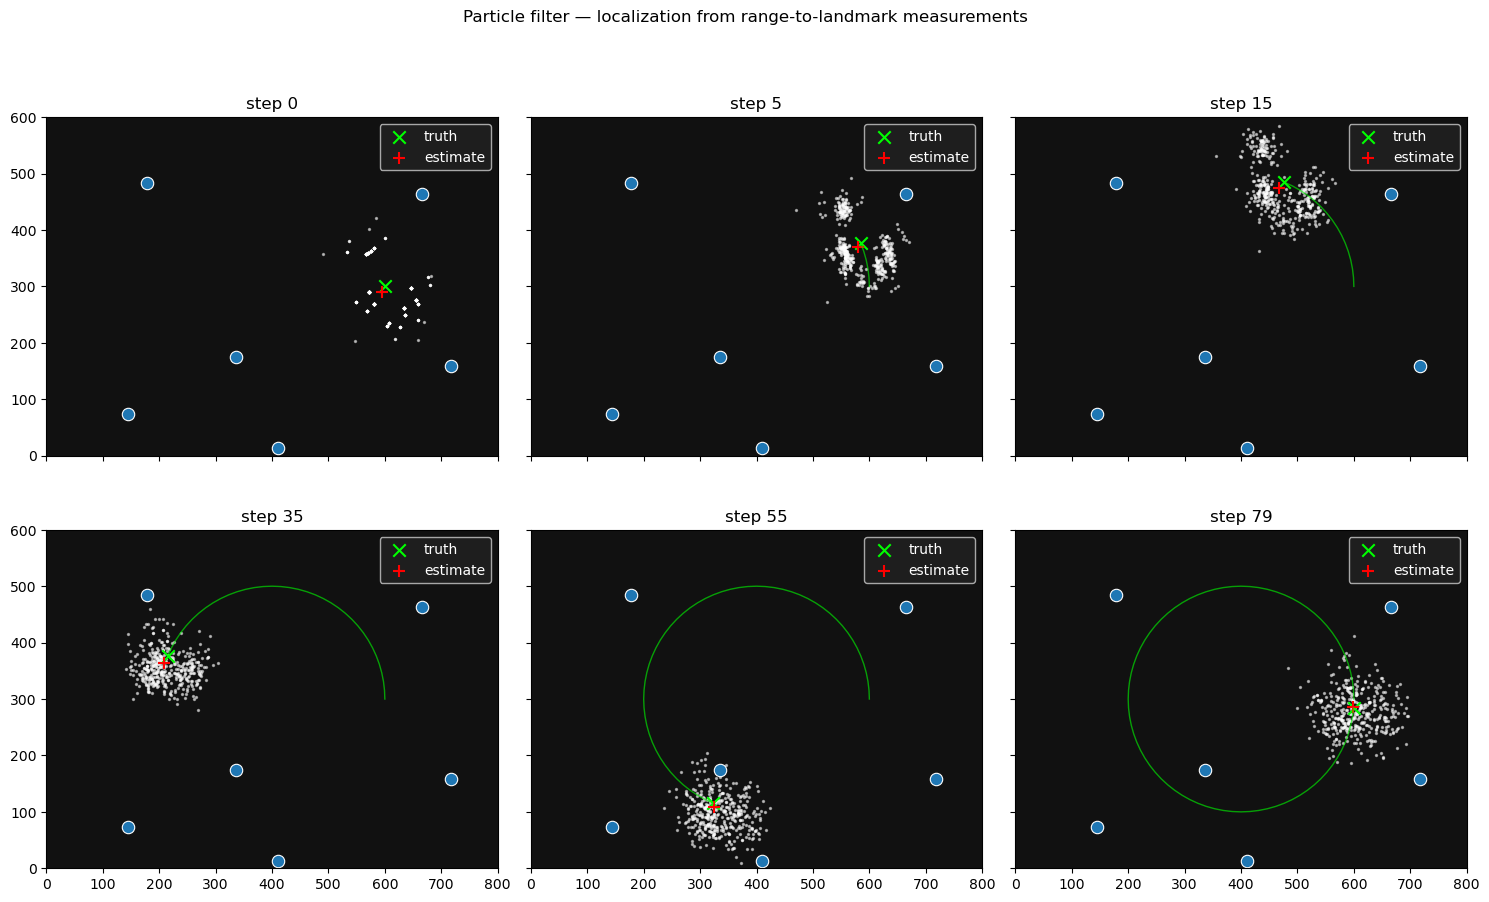

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True, sharey=True)

for ax_p, (t, (parts, mean_pos, true_pose)) in zip(axes.flat, snapshots.items()):
    ax_p.set_xlim(0, WORLD_W)
    ax_p.set_ylim(0, WORLD_H)
    ax_p.set_aspect("equal")
    ax_p.set_facecolor("#111")
    ax_p.set_title(f"step {t}")

    # True trajectory so far
    ax_p.plot(truth[: t + 1, 0], truth[: t + 1, 1], "-", c="lime", lw=1, alpha=0.6)
    # Particles
    ax_p.scatter(parts[:, 0], parts[:, 1], s=2, c="white", alpha=0.5)
    # Landmarks
    ax_p.scatter(landmarks[:, 0], landmarks[:, 1], s=80, c="C0", marker="o",
                 edgecolors="white", linewidths=0.8)
    # Truth + estimate
    ax_p.scatter(*true_pose, s=80, c="lime", marker="x", label="truth")
    ax_p.scatter(*mean_pos,  s=80, c="red",  marker="+", label="estimate")
    ax_p.legend(loc="upper right", facecolor="#222", labelcolor="white")

plt.suptitle("Particle filter — localization from range-to-landmark measurements", y=1.02)
plt.tight_layout()
plt.show()


## What to look at

* At **step 0** the particles are spread uniformly — the filter has no
  prior on where the robot is.
* Within a handful of updates the cloud collapses onto the true
  trajectory. Multi-modal "guesses" (ghost clusters in symmetric regions)
  are pruned as more measurements arrive.
* The **red +** estimate (weighted mean of particles) sits on the **green
  ×** truth once the filter has converged.
* Try increasing `SENSOR_STD` — the cloud will be more diffuse. Drop `N`
  below ~100 and the filter starts to lose the truth on the curved
  sections.
